# Post-Pandemic Gender Labor Force Trends
Principle Investigators: Abigail Garvey, Anna Wang, Rachelle Lang - Group Q

Part 1: Panel of Gender Participation Rates Over Time

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.tsa.api as tsa

import warnings
warnings.filterwarnings("ignore")

**Part A: Timeseries Forecasting and Analysis**

In [2]:
lfpr = pd.read_csv('../Data/lfpr.csv')
lfpr.tail()

,date,men,women
927,2025-04-01,68.1,57.5
928,2025-05-01,67.8,57.2
929,2025-06-01,67.8,57.0
930,2025-07-01,67.6,57.1
931,2025-08-01,68.0,56.9


In [3]:
industries = pd.read_csv('../Data/industries.csv')
industries.head()

,indy_code,occupation_code,date,employed_men,employed_women,employed_total,pct_men,pct_women
0,0,7,1983-01-01,16410.0,12123.0,28533.0,0.575124,0.424876
1,0,7,1983-02-01,16355.0,12225.0,28580.0,0.572253,0.427747
2,0,7,1983-03-01,16491.0,12201.0,28692.0,0.574760,0.425240
3,0,7,1983-04-01,16759.0,12366.0,29125.0,0.575416,0.424584
4,0,7,1983-05-01,16825.0,12367.0,29192.0,0.576357,0.423643


In [4]:
lfpr.set_index('date', inplace=True)
lfpr.index = pd.DatetimeIndex(lfpr.index.values, name = 'date')
lfpr.head()

,men,women
date,,
1948-01-01,86.7,32.0
1948-02-01,87.0,32.4
1948-03-01,86.3,32.1
1948-04-01,86.6,33.0
1948-05-01,86.1,32.0


In [5]:
all_series = pd.read_csv('../BLS/ln.series.txt', sep='\t')
all_series.head(3)

,series_id,lfst_code,periodicity_code,series_title,absn_code,activity_code,ages_code,cert_code,class_code,duration_code,...,born_code,chld_code,disa_code,seasonal,tlwk_code,footnote_codes,begin_year,begin_period,end_year,end_period
0,LNS11000000,10,M,(Seas) Civilian Labor Force Level,0,0,0,0,0,0,...,0,0,0,S,0,NaN,1948,M01,2025,M08
1,LNS11000000Q,10,Q,(Seas) Civilian Labor Force Level,0,0,0,0,0,0,...,0,0,0,S,0,NaN,1948,Q01,2025,Q02
2,LNS11000001,10,M,(Seas) Civilian Labor Force Level - Men,0,0,0,0,0,0,...,0,0,0,S,0,NaN,1948,M01,2025,M08


**Step 1: Assess the trend in male participation rate**

1. Check for stationarity

In [6]:
#check for male stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(lfpr['men'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: -0.9045035468804143
p-value: 0.7864857172594357


A p-value of .78 is not significant, so we can not reject the null hypothesis of non-stationarity. So we will have to adjust our trend analysis and look at the differences over time.

In [7]:
#It is not stationary - calculating the trend differences to satisfy stationarity
lfpr['men_diff'] = lfpr['men'].diff().dropna()
lfpr

,men,women,men_diff
date,,,
1948-01-01,86.7,32.0,NaN
1948-02-01,87.0,32.4,0.3
1948-03-01,86.3,32.1,-0.7
1948-04-01,86.6,33.0,0.3
1948-05-01,86.1,32.0,-0.5
...,...,...,...
2025-04-01,68.1,57.5,0.3
2025-05-01,67.8,57.2,-0.3
2025-06-01,67.8,57.0,0.0


2. Check how many lags

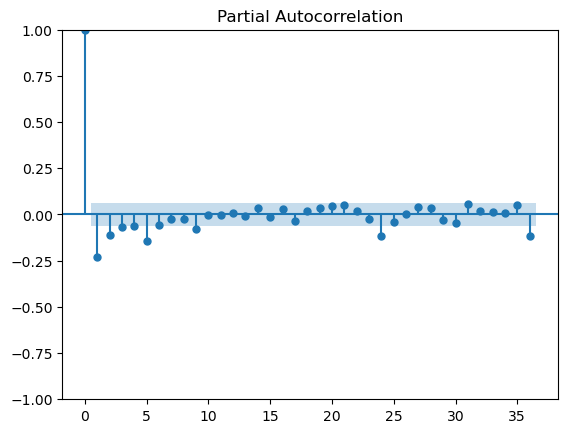

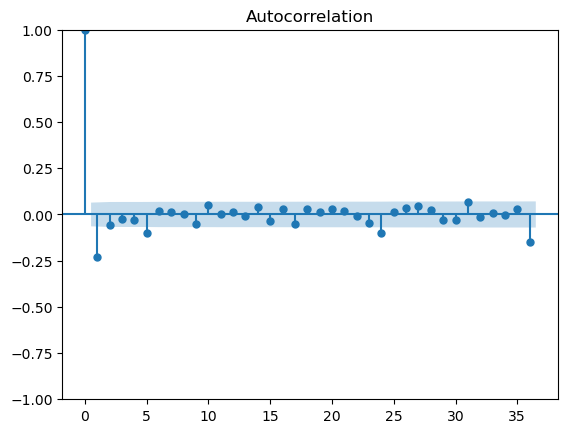

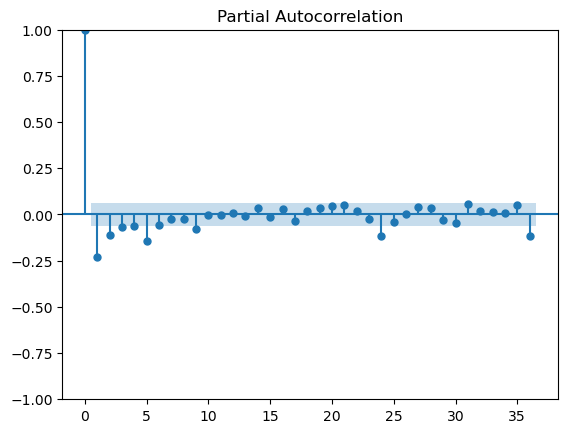

In [8]:
#plot acf to determine number of lags
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
lfpr = lfpr.dropna(subset=['men_diff'])
plot_acf(lfpr['men_diff'], lags=36)
plot_pacf(lfpr['men_diff'], lags=36)

There is a clear spike at 1. From this we can draw 2 conclusions: 1) the data is not stationary, so we need to use the differences, and 2) when autoregressing those differences data, we will use 1 lag.

3. Autoregression

In [9]:
#Autoregression of Men's Participation Rates
lfpr_mreg = tsa.AutoReg(lfpr['men_diff'], lags=1).fit()
print(lfpr_mreg.summary())

                            AutoReg Model Results                             
Dep. Variable:               men_diff   No. Observations:                  931
Model:                     AutoReg(1)   Log Likelihood                  57.335
Method:               Conditional MLE   S.D. of innovations              0.228
Date:                Fri, 12 Dec 2025   AIC                           -108.671
Time:                        21:15:39   BIC                            -94.165
Sample:                    03-01-1948   HQIC                          -103.138
                         - 08-01-2025                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0252      0.007     -3.360      0.001      -0.040      -0.010
men_diff.L1    -0.2305      0.032     -7.219      0.000      -0.293      -0.168
                                    Roots       

The mens.L1 coefficient represents the first lag, how much the most recent previous year had on the current one. The coefficient of -.2305  means that, holding the second lag constant, a 1-unit (e.g. 1 percentage point) increase in last period’s participation rate is associated with a .2305 unit decrease in the change of this period’s participation rate. The p-value is 0.000, which is highly significant.

This suggests an overall negative trend in the differences of male labor participation over time.

In [10]:
#Forecasting this regression 60 months (5 years)
men_predictions = lfpr_mreg.forecast(60)
men_predictions.head()

2025-09-01   -0.117369
2025-10-01    0.001891
2025-11-01   -0.025600
2025-12-01   -0.019263
2026-01-01   -0.020724
Freq: MS, dtype: float64

**Step 2: Assess the trend in female labor participation rate**

1. Check for stationarity

In [11]:
#check for female stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(lfpr['women'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: -2.6865475656483784
p-value: 0.07639519647975089


The female p-value of staionarity of .076 is more significant than the male p-value, but still not significant at .05. Also, it would be best to compare the trend of differences in both men and women (rather than the trend of differences in men and the general trend of women's participation rates).

In [12]:
lfpr['women_diff'] = lfpr['women'].diff().dropna()
lfpr

,men,women,men_diff,women_diff
date,,,,
1948-02-01,87.0,32.4,0.3,NaN
1948-03-01,86.3,32.1,-0.7,-0.3
1948-04-01,86.6,33.0,0.3,0.9
1948-05-01,86.1,32.0,-0.5,-1.0
1948-06-01,86.6,33.4,0.5,1.4
...,...,...,...,...
2025-04-01,68.1,57.5,0.3,0.0
2025-05-01,67.8,57.2,-0.3,-0.3
2025-06-01,67.8,57.0,0.0,-0.2


2. Check how many lags

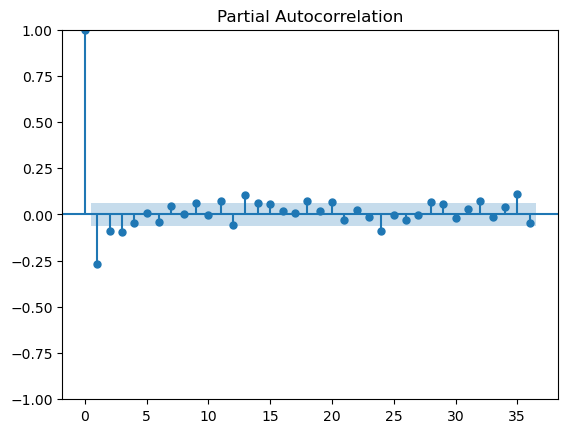

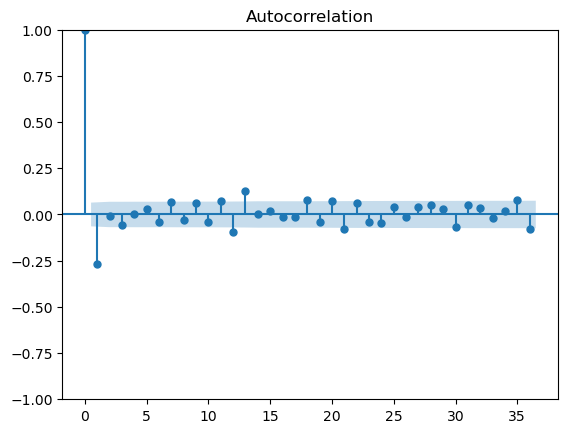

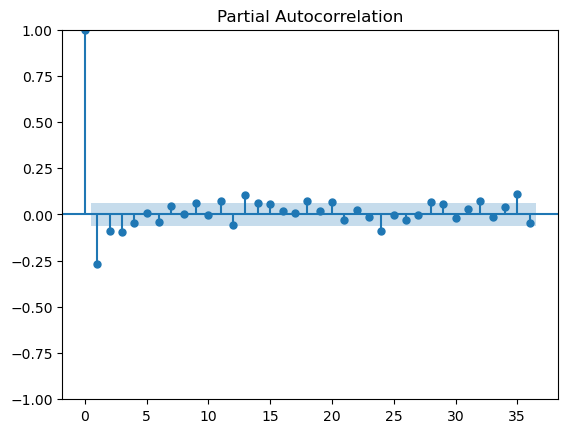

In [13]:
lfpr = lfpr.dropna(subset=['women_diff'])
plot_acf(lfpr['women_diff'], lags=36)
plot_pacf(lfpr['women_diff'], lags=36)

Once again, the PACF and ACF trends suggest that we should use one lag.

3. Autoregression

In [14]:
#Autoregression of Womens Labor Force Participation Rates
lfpr_wreg = tsa.AutoReg(lfpr['women_diff'], lags=1).fit()
print(lfpr_wreg.summary())

                            AutoReg Model Results                             
Dep. Variable:             women_diff   No. Observations:                  930
Model:                     AutoReg(1)   Log Likelihood                 -41.247
Method:               Conditional MLE   S.D. of innovations              0.253
Date:                Fri, 12 Dec 2025   AIC                             88.494
Time:                        21:15:41   BIC                            102.996
Sample:                    04-01-1948   HQIC                            94.025
                         - 08-01-2025                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0339      0.008      4.061      0.000       0.018       0.050
women_diff.L1    -0.2699      0.032     -8.547      0.000      -0.332      -0.208
                                    Root

The women's labor force participation rates follow a very similar trend to the men's. The coefficient of the first lag is-0.2699, meaning that a one percent increase in the difference in participation in the most previous period is associated with .27 percentage points decrease in the current period, and it is statistically significant.

The change in women's labor force participation rates also seem to be decreasing.

In [15]:
#Forecasting women's participation rates out to 60 months (5 years)
women_predictions = lfpr_wreg.forecast(60)
women_predictions.head()

2025-09-01    0.087848
2025-10-01    0.010162
2025-11-01    0.031128
2025-12-01    0.025470
2026-01-01    0.026997
Freq: MS, dtype: float64

In [16]:
#adding both predicitions to one dataframe
lfpr['male_forecast'] = 0
predictions = men_predictions.to_frame()
predictions.columns = ['male_part_rate_predict']
predictions['female_part_rate_predict'] = women_predictions
predictions.head(3)

,male_part_rate_predict,female_part_rate_predict
2025-09-01,-0.117369,0.087848
2025-10-01,0.001891,0.010162
2025-11-01,-0.025600,0.031128


**Step 3: Plot and compare**

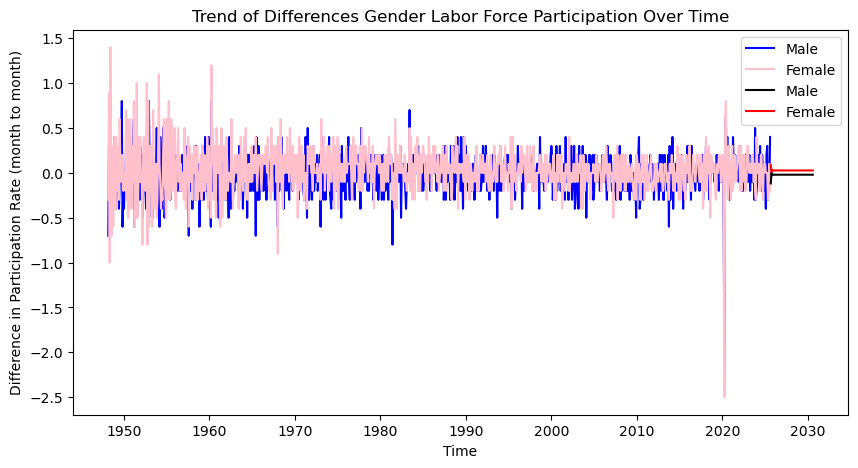

In [17]:
#plot
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(lfpr.index, lfpr['men_diff'], color='blue', label='Male')
ax.plot(lfpr.index, lfpr['women_diff'], color='pink', label='Female')
ax.plot(predictions.index, predictions['male_part_rate_predict'], color='black',label='Male')
ax.plot(predictions.index, predictions['female_part_rate_predict'], color='red',label='Female')
ax.set_title('Trend of Differences Gender Labor Force Participation Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Difference in Participation Rate (month to month)')
ax.legend()




plt.show()

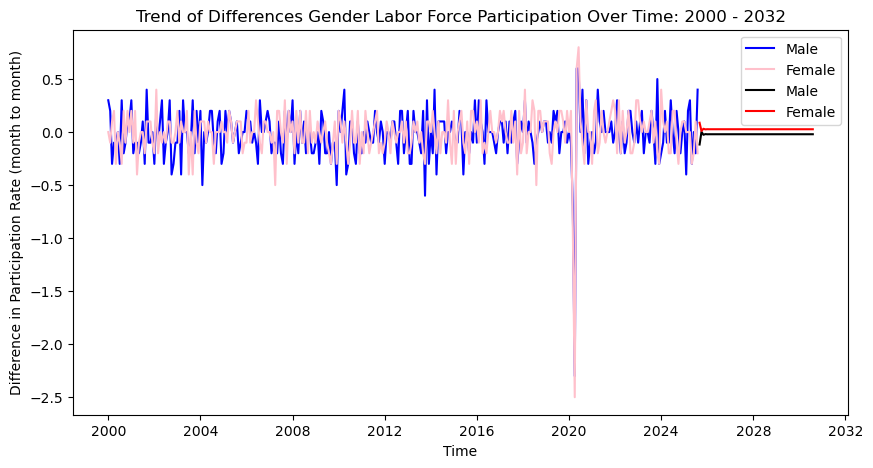

In [18]:
#taking a closer look at the pandemic
lfpr_zoom = lfpr.loc['2000':]
predictions_zoom = predictions.loc['2000':]

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(lfpr_zoom.index, lfpr_zoom['men_diff'], color='blue', label='Male')
ax.plot(lfpr_zoom.index, lfpr_zoom['women_diff'], color='pink', label='Female')
ax.plot(predictions_zoom.index, predictions_zoom['male_part_rate_predict'], color='black', label='Male')
ax.plot(predictions_zoom.index, predictions_zoom['female_part_rate_predict'], color='red', label='Female')
ax.set_title('Trend of Differences Gender Labor Force Participation Over Time: 2000 - 2032')
ax.set_xlabel('Time')
ax.set_ylabel('Difference in Participation Rate (month to month)')
ax.legend()

plt.show()

It should be noted that this graph is an extrapolation of real data and should be taken with some considerations and understanding.

The visualization of the trend of month-to-month differences of both men and women's participation rates clearly demonstrates that the men participation rate took a significant drop around the 2020 pandemic that the women did not. But have the men's participation rate recovered back to where it was? Further investigation into possible variable will answer that questions.